In [1]:
print("Hello!")

Hello!


<img src="rat.jpg.png" width="500">

# Rat Olfactory Bulb Electrophysiology Dataset
## Overview
This dataset contains electrophysiological recordings from the olfactory bulb of an adult rat using 8×8 microelectrode array.
The recording captures 11 minutes sampled at 30 kHz from 64 channel.

The data are organized as a continuous recording with shape:
```text
(21,150,000 samples, 64 channels)
```

- Sampling frequency: 30,000 Hz
- Number of channels: 64
- Electrode layout: 8 × 8 microelectrode array
- Recording duration: approximately 705 seconds (~11 minutes)

The dataset includes:

- Continuous recording
- Spike times 

In [32]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neo
from scipy.signal import spectrogram
from neo.io import NixIO
from viziphant.rasterplot import rasterplot

## Data Structure

1. Block
2. Segment
3. Analog Signal (64 channels)
3. SpikeTrain (unit_32)
3. SpikeTrain (unit_36)
3. SpikeTrain (unit_38)



# Block

In [3]:
with NixIO("rat_retreat_meta_1kHz.nix", mode="ro") as io:
    block_check = io.read_block()

seg_check = block_check.segments[0]

print(block_check.description)
print(seg_check.description)

for st in seg_check.spiketrains:
    print(st.name, st.annotations)

species=Rattus norvegicus; brain_region=olfactory bulb
ketamine_injection_time_s=372; baseline_interval_s=0-372; post_ketamine_interval_s=372-705.0; electrode_array=NeuroNexus 8x8; recording_type=extracellular electrophysiology
cluster_32_Ch_25 {'nix_name': 'neo.spiketrain.c76d122c03444f34b75d78948704b9e1', 'spike_id': np.int64(32), 'channel': 'Ch_25', 'unit_type': 'single_unit'}
cluster_36_Ch_19 {'nix_name': 'neo.spiketrain.c9644431442549cfb421e334835e3884', 'spike_id': np.int64(36), 'channel': 'Ch_19', 'unit_type': 'single_unit'}
cluster_38_Ch_30 {'nix_name': 'neo.spiketrain.b41c0e28a54049e08985e1638e93b96d', 'spike_id': np.int64(38), 'channel': 'Ch_30', 'unit_type': 'single_unit'}
cluster_40_Ch_30 {'nix_name': 'neo.spiketrain.6dd0e670997e49609a57bb78910059bf', 'spike_id': np.int64(40), 'channel': 'Ch_30', 'unit_type': 'multi_unit'}
cluster_31_Ch_25 {'nix_name': 'neo.spiketrain.50b545951cc9495fa94d09141b8831df', 'spike_id': np.int64(31), 'channel': 'Ch_25', 'unit_type': 'multi_unit'}

In [3]:
print(block_check.description)

species=Rattus norvegicus; brain_region=olfactory bulb


In [4]:
print(seg_check.description)

ketamine_injection_time_s=372; baseline_interval_s=0-372; post_ketamine_interval_s=372-705.0; electrode_array=NeuroNexus 8x8; recording_type=extracellular electrophysiology


In [5]:
for st in seg_check.spiketrains:
    print(st.name, st.annotations)

cluster_32_Ch_25 {'nix_name': 'neo.spiketrain.c76d122c03444f34b75d78948704b9e1', 'spike_id': np.int64(32), 'channel': 'Ch_25', 'unit_type': 'single_unit'}
cluster_36_Ch_19 {'nix_name': 'neo.spiketrain.c9644431442549cfb421e334835e3884', 'spike_id': np.int64(36), 'channel': 'Ch_19', 'unit_type': 'single_unit'}
cluster_38_Ch_30 {'nix_name': 'neo.spiketrain.b41c0e28a54049e08985e1638e93b96d', 'spike_id': np.int64(38), 'channel': 'Ch_30', 'unit_type': 'single_unit'}
cluster_40_Ch_30 {'nix_name': 'neo.spiketrain.6dd0e670997e49609a57bb78910059bf', 'spike_id': np.int64(40), 'channel': 'Ch_30', 'unit_type': 'multi_unit'}
cluster_31_Ch_25 {'nix_name': 'neo.spiketrain.50b545951cc9495fa94d09141b8831df', 'spike_id': np.int64(31), 'channel': 'Ch_25', 'unit_type': 'multi_unit'}
cluster_41_Ch_30 {'nix_name': 'neo.spiketrain.1cb160428de24a7ba34ee5ed3368390b', 'spike_id': np.int64(41), 'channel': 'Ch_30', 'unit_type': 'multi_unit'}
cluster_39_Ch_30 {'nix_name': 'neo.spiketrain.1c92409695f04c058397aa659da

# Segment

In [5]:
seg = block_check.segments[0]
print(seg)

# Analog Signal

In [6]:
sig = seg.analogsignals[0]

In [7]:
sig

AnalogSignal with 64 channels of length 705000; units V; datatype float64
name: 'continuous_signal'
annotations: {'nix_name': 'neo.analogsignal.6ec8c4a4b75646458bb178ea393b4fb7'}
sampling rate: 1000.0 Hz
time: 0.0 s to 705.0 s

In [8]:
print(sig.shape)

(705000, 64)


In [9]:
print(sig.sampling_rate)

1000.0 Hz


## Experimental Design

The recording consists of three phases:

1. **Baseline activity**
   
   Activity before ketamine administration.

2. **Ketamine administration**
   
   Systemic ketamine injection.

3. **Post-ketamine activity**
   
   Activity recorded following ketamine administration.




In [143]:
signal = np.asarray(sig[:, 18]).squeeze() #example channel

In [144]:
fs = float(sig.sampling_rate)

In [145]:
times = np.arange(len(signal)) / fs

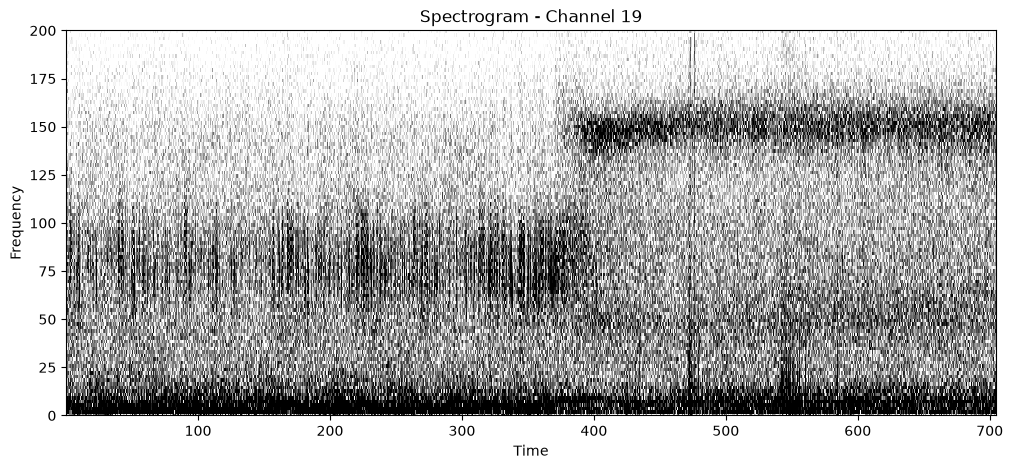

In [85]:
f, t, Sxx = spectrogram(signal, fs=fs, nperseg=16384)
power = 10 * np.log10(Sxx+1e-20)
plt.figure(figsize=(12, 5))
plt.pcolormesh(
    t,
    f,
    power,
    shading="auto",
    cmap="Greys",
    vmin=-115,
    vmax=-95
)
plt.ylim(0, 200)
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title("Spectrogram - Channel 19")
plt.show()

The spectrogram shows gamma-band activity during the baseline period. 
Following ketamine administration, there is an increase in high-frequency oscillation power around 150 Hz.
It is a marked change in olfactory bulb network dynamics after keramine manipulation.

In [175]:
signal = np.asarray(sig[:, 19]).squeeze() # example channel from 0-63 

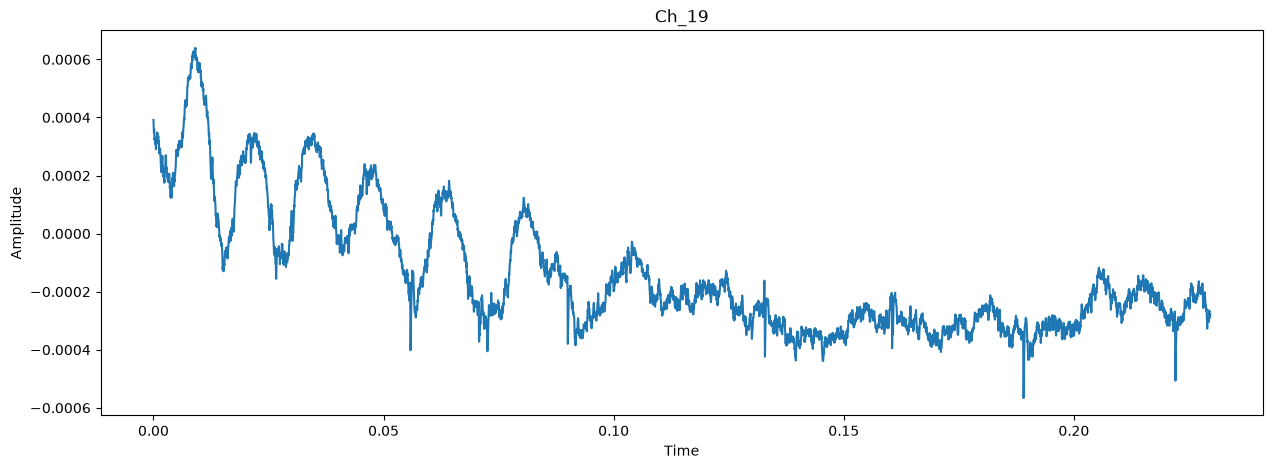

In [176]:
plt.figure(figsize=(15, 5))
plt.plot(
    times[0:6890],
    signal[0:6890]
)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Ch_19")
plt.show()

My goal: understand single unit properties

I would like to use this dataset to learn how to explore and characterize neuronal spike trains. 
- basic spiking statistics such as firing rates, inter-spike interval distributions, and the Fano factor
- examine the relationship between spiking activity and network oscillations observed in the local field potential.
The recording contains a baseline period dominated by gamma-band activity and a ketamine period HFO ~150 Hz. the question is, how neuronal firing patterns relate to different oscillatory states?

My one idea: PCA
**Apply PCA to the 11-minute recording (baseline + ketamine)**

For example: if I apply PCA ,the first principal component will capture the largest source of variance in the dataset

And this may correspond to:
- the transition from the baseline state to the ketamine state,
- the high-frequency oscillations induced by ketamine,

What interests me the most is spiking activity. If there will be a component that represents spiking activity?

For example, if HFO are the largest source of variance in the recording, the principal components might look something like this:
- PC1 – ketamine-induced HFO activity
- PC2 – some spatial patterns across recording channels
- PC3 – activity characteristic of the baseline period

Spiking activity, on the other hand, may be represented:
- as individual component, is spiking activity has some representative pattern by itself
- partly by PC2 or PC3
- or distributed across multiple principal components? all spikes or some of them?

After extracting the principal components, I would like to investigate questions such as:
- Do spikes occur more frequently when a particular component has a high value?
- Is the firing rate correlated with particular component?

PCA is a reduction and in summary: my goal is to learn how to interpret the resulting principal components in a meaningful context 

- time point of ketamine injection
- spike trains include in metadeta and what type of unit
- downsampling the signal 5kHz
- mua

Project plan:

- PCA
- anatomical structre related to what PCA
- which channel related to anatomical structure
- phase locking to LFP oscillations

In [10]:
from sklearn.decomposition import PCA

In [11]:
print(sig.T.shape)

(64, 705000)


In [12]:
X = np.asarray(sig)
print(X.shape)

(705000, 64)


In [13]:
pca = PCA()
scores = pca.fit_transform(X)

In [14]:
scores.shape

(705000, 64)

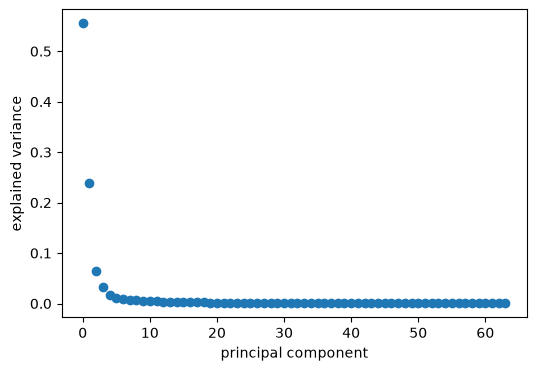

In [15]:
plt.figure(figsize=(6,4))
plt.plot(pca.explained_variance_ratio_, "o")
plt.xlabel("principal component")
plt.ylabel("explained variance")
plt.show()

C:\Users\abramorska\Desktop\ANDA\andani_retreat\.pixi\envs\default\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


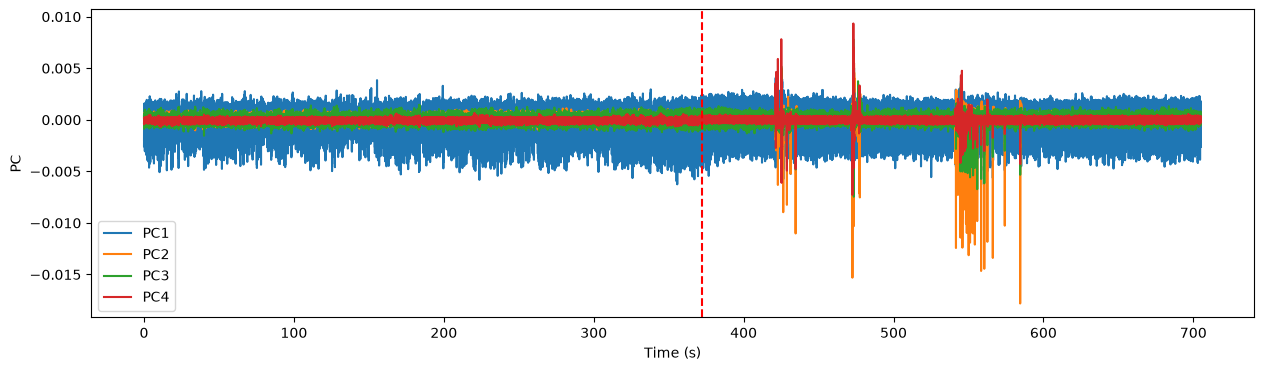

In [16]:
times = sig.times.rescale("s").magnitude
plt.figure(figsize=(15,4))
plt.plot(times, scores[:,0], label="PC1")
plt.plot(times, scores[:,2], label="PC2")
plt.plot(times, scores[:,3], label="PC3")
plt.plot(times, scores[:,4], label="PC4")
plt.axvline(372, color="red", linestyle="--",)
plt.xlabel("Time (s)")
plt.ylabel("PC")
plt.legend()
plt.show()

(64, 64)


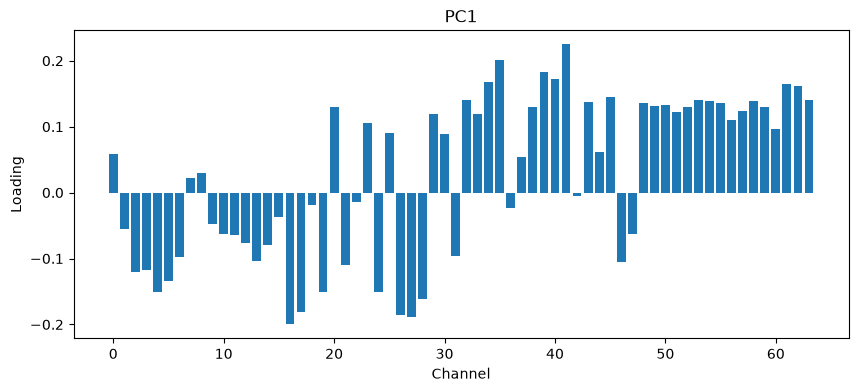

In [20]:
loadings = pca.components_
print(loadings.shape)
plt.figure(figsize=(10,4))
plt.bar(np.arange(64), loadings[0])
plt.xlabel("Channel")
plt.ylabel("Loading")
plt.title("PC1")
plt.show()

In [18]:
st = seg_check.spiketrains[0]
spike_times_s = st.times.rescale("s").magnitude
bin_size = 1.0  
t_start = float(st.t_start.rescale("s").magnitude)
t_stop = float(st.t_stop.rescale("s").magnitude)
bin_edges = np.arange(t_start, t_stop + bin_size, bin_size)
spike_counts, _ = np.histogram(spike_times_s, bins=bin_edges)
firing_rate = spike_counts / bin_size
bin_centers = bin_edges[:-1] + bin_size / 2

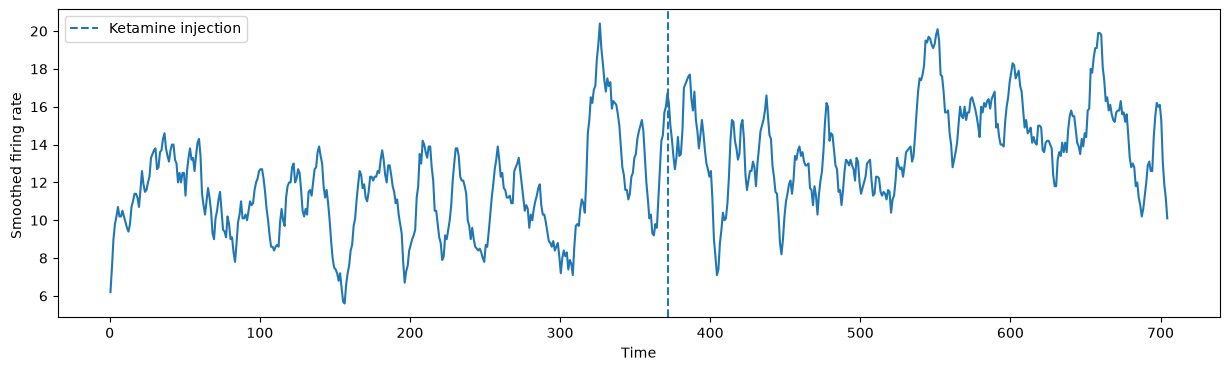

In [21]:
window_s = 10
kernel = np.ones(window_s) / window_s
firing_rate_smooth = np.convolve(firing_rate, kernel, mode="same")

plt.figure(figsize=(15, 4))
plt.plot(bin_centers, firing_rate_smooth)
plt.axvline(372, linestyle="--", label="Ketamine injection")
plt.xlabel("Time")
plt.ylabel("Smoothed firing rate ")
plt.legend()
plt.show()

In [22]:
firing_rates = {}
bin_size = 1.0
bin_edges = np.arange(0, 705 + bin_size, bin_size)
bin_centers = bin_edges[:-1] + bin_size / 2
for st in seg_check.spiketrains:
    spike_times_s = st.times.rescale("s").magnitude
    counts, _ = np.histogram(
        spike_times_s,
        bins=bin_edges
    )
    firing_rates[st.name] = counts / bin_size

In [25]:
injection_time = 372
baseline_mask = bin_centers < injection_time
post_mask = bin_centers >= injection_time
for name, fr in firing_rates.items():
    baseline_fr = fr[baseline_mask].mean()
    post_fr = fr[post_mask].mean()
    print(name,"baseline:", round(baseline_fr, 2),"Hz | ket:", round(post_fr, 2),"Hz")

cluster_32_Ch_25 baseline: 11.42 Hz | ket: 14.16 Hz
cluster_36_Ch_19 baseline: 16.41 Hz | ket: 25.1 Hz
cluster_38_Ch_30 baseline: 5.54 Hz | ket: 9.31 Hz
cluster_40_Ch_30 baseline: 12.11 Hz | ket: 17.5 Hz
cluster_31_Ch_25 baseline: 13.06 Hz | ket: 13.15 Hz
cluster_41_Ch_30 baseline: 8.63 Hz | ket: 10.89 Hz
cluster_39_Ch_30 baseline: 7.56 Hz | ket: 11.17 Hz
cluster_35_Ch_19 baseline: 6.01 Hz | ket: 11.71 Hz
cluster_51_Ch_0 baseline: 4.92 Hz | ket: 7.74 Hz
cluster_7_Ch_63 baseline: 3.26 Hz | ket: 6.21 Hz
cluster_48_Ch_28 baseline: 2.92 Hz | ket: 1.42 Hz
cluster_60_Ch_63 baseline: 2.06 Hz | ket: 0.35 Hz
cluster_18_Ch_37 baseline: 0.98 Hz | ket: 1.38 Hz


In [29]:
sts = [st for st in seg.spiketrains]

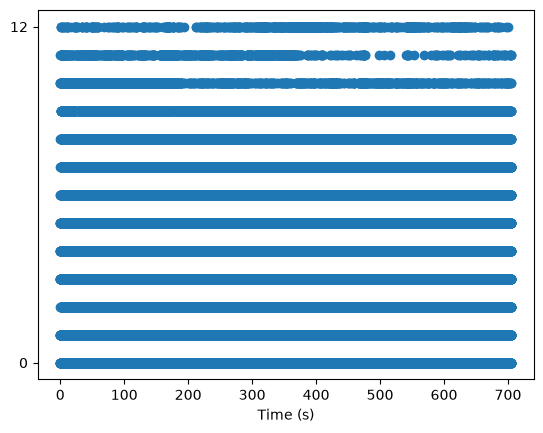

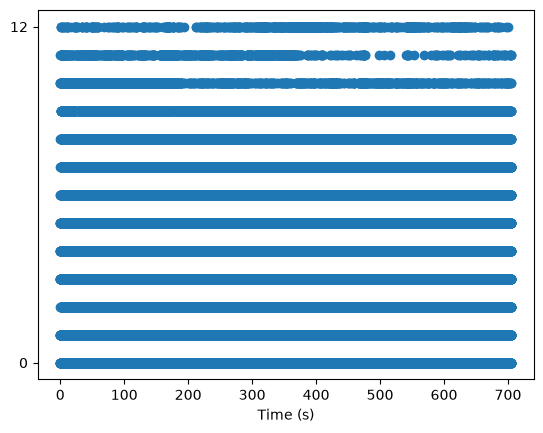

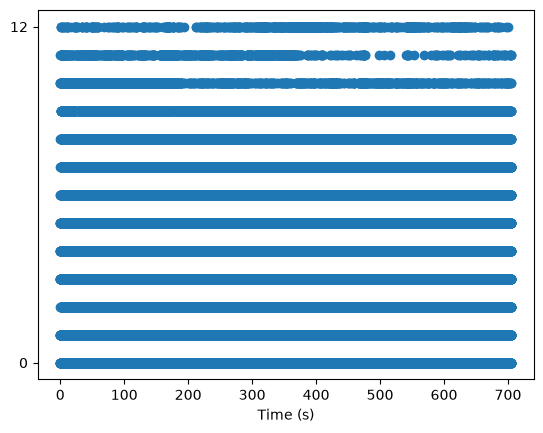

In [33]:
rasterplot(sts)
plt.show()